# 📘 Project 23 — Emotion-Aware Adaptive Learning
**Team No.:** 10  **Team Members:** Ankita Panda; Arpita Mishra; Banaja Manjari Das

**Proposed Hybrid Model:** Video CNN + Speech Transformer + Text Transformer + Policy Network

**Dataset / Source:** MELD (Multimodal EmotionLines Dataset)
**Dataset Link:** https://www.kaggle.com/datasets/zaber666/meld-dataset

**Task Type:** Multiclass classification — utterance emotion recognition

---
## Data-Model Compatibility Note
MELD is a genuinely strong fit: real synchronized video clips + speech audio + dialogue text per
utterance, each labeled with an emotion. All three perception branches map onto real modalities:
- **Video CNN**: sampled frames from each utterance's video clip, through a small 2D CNN.
- **Speech Transformer**: log-mel spectrogram of the utterance's extracted audio, through a
  self-attention encoder (spectrogram treated as a time x frequency sequence).
- **Text Transformer**: the utterance's dialogue text, through a token-level self-attention encoder.
- **Policy Network**: MELD has no real "adaptive learning" environment (no student model, no
  curriculum feedback loop) - the "adaptive learning" framing is a downstream application of the
  emotion signal, not something present in this dataset. Reduced to a documented lightweight policy
  head that maps the fused emotion representation to a next-action distribution over a small fixed
  action set (e.g. simplify/maintain/challenge), trained with a heuristic reward tied to the
  emotion label (proxy for "did the learner seem engaged") - explicitly flagged as a scoped-down
  stand-in, not a real adaptive-learning system.

**Verdict: PARTIAL** - video/audio/text branches are faithful; Policy Network is a documented,
reduced-scope proxy since no real adaptive-learning environment exists in MELD.

**Colab resource note**: video/audio decoding is the most expensive part of this pipeline - the
notebook caps clips processed and frames/spectrogram length for feasibility on free-tier Colab.

**How to run:** `Runtime -> Change runtime type -> GPU`, then `Runtime -> Run all`. Upload your
Kaggle API token when prompted in Section 1.


## 0. Setup — Environment, Imports, Reproducibility

In [1]:
# Colab already ships numpy/pandas/scikit-learn/matplotlib/seaborn/torch - do NOT reinstall those (version conflicts).
# Only install what's actually missing.
!pip -q install kaggle tqdm opencv-python-headless librosa moviepy tabulate


In [2]:
import os, sys, json, random, platform, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, average_precision_score

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()
assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."
DEVICE = torch.device("cuda:0")
print("Python:", sys.version.split()[0]); print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available()); print("Device selected:", DEVICE)
if torch.cuda.is_available(): print("GPU name:", torch.cuda.get_device_name(0))


Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
Device selected: cuda:0
GPU name: Tesla T4


### CONFIG

In [3]:
CONFIG = {
    "project_no": "23",
    "project_name": "Emotion-Aware_Adaptive_Learning",
    "team_no": "10",
    "task_type": "classification",
    "kaggle_dataset_slug": "zaber666/meld-dataset",
    "dataset_source": "MELD (Multimodal EmotionLines Dataset)",
    "max_clips": 600,      # bounded Colab runtime; raise for a longer experiment
    "n_frames": 2,          # frames sampled per video clip
    "frame_size": 64,
    "n_mels": 40,
    "audio_max_frames": 100,
    "max_text_len": 40,
    "max_vocab": 4000,
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "random_seed": SEED,
    "embed_dim": 64,
    "n_policy_actions": 3,  # simplify / maintain / challenge
    "batch_size": 16,
    "epochs": 8,
    "learning_rate": 1e-3,
    "early_stop_patience": 5,
    "data_raw_dir": "data/23/raw",
    "data_processed_dir": "data/23/processed",
    "figures_dir": "data/23/figures",
    "results_dir": "data/23/results",
    "reports_dir": "data/23/reports",
}
for d in [CONFIG["data_raw_dir"], CONFIG["data_processed_dir"], CONFIG["figures_dir"],
          CONFIG["results_dir"], CONFIG["reports_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG


{'project_no': '23',
 'project_name': 'Emotion-Aware_Adaptive_Learning',
 'team_no': '10',
 'task_type': 'classification',
 'kaggle_dataset_slug': 'zaber666/meld-dataset',
 'dataset_source': 'MELD (Multimodal EmotionLines Dataset)',
 'max_clips': 600,
 'n_frames': 2,
 'frame_size': 64,
 'n_mels': 40,
 'audio_max_frames': 100,
 'max_text_len': 40,
 'max_vocab': 4000,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'embed_dim': 64,
 'n_policy_actions': 3,
 'batch_size': 16,
 'epochs': 8,
 'learning_rate': 0.001,
 'early_stop_patience': 5,
 'data_raw_dir': 'data/23/raw',
 'data_processed_dir': 'data/23/processed',
 'figures_dir': 'data/23/figures',
 'results_dir': 'data/23/results',
 'reports_dir': 'data/23/reports'}

## 1. Dataset Download

In [4]:
from google.colab import files
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Upload your kaggle.json:")
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fname in uploaded:
        if fname.endswith(".json"):
            os.replace(fname, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d {CONFIG["kaggle_dataset_slug"]} -p {CONFIG["data_raw_dir"]} --unzip


Dataset URL: https://www.kaggle.com/datasets/zaber666/meld-dataset
License(s): CC0-1.0


In [5]:
raw_files = []
for root, _, fnames in os.walk(CONFIG["data_raw_dir"]):
    for fn in fnames:
        raw_files.append(os.path.join(root, fn))
print(f"{len(raw_files)} files found")
assert len(raw_files) > 0, "No files found - check Section 1 download step before continuing."

video_files = [f for f in raw_files if f.lower().endswith((".mp4", ".avi", ".mov"))]
csv_files = [f for f in raw_files if f.lower().endswith(".csv")]
print("Video files:", len(video_files), "| CSV files:", len(csv_files))


15934 files found
Video files: 15908 | CSV files: 3


## 2. Load Raw Data

In [6]:
assert len(csv_files) >= 1, f"No utterance-metadata CSV found among: {raw_files[:15]}"
RAW_FILE = max(csv_files, key=os.path.getsize)
print("Using metadata CSV:", RAW_FILE)

meta_df = pd.read_csv(RAW_FILE)
print(meta_df.shape)
print(list(meta_df.columns))
meta_df.head()


Using metadata CSV: data/23/raw/MELD-RAW/MELD.Raw/train/train_sent_emo.csv
(9989, 11)
['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID', 'Utterance_ID', 'Season', 'Episode', 'StartTime', 'EndTime']


,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
0,1,also I was the point person on my companys tr...,Chandler,neutral,neutral,0,0,8,21,"00:16:16,059","00:16:21,731"
1,2,You mustve had your hands full.,The Interviewer,neutral,neutral,0,1,8,21,"00:16:21,940","00:16:23,442"
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21,"00:16:23,442","00:16:26,389"
3,4,So lets talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21,"00:16:26,820","00:16:29,572"
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21,"00:16:34,452","00:16:40,917"


## 3. Exploratory Data Analysis (EDA)

In [7]:
text_candidates = [c for c in meta_df.columns if c.lower() in ("utterance", "text", "dialogue")]
emotion_candidates = [c for c in meta_df.columns if c.lower() in ("emotion", "label")]
video_id_candidates = [c for c in meta_df.columns if any(k in c.lower() for k in ["dialogue_id", "utterance_id", "filename", "video"])]
assert len(text_candidates) >= 1 and len(emotion_candidates) >= 1, f"Could not find text/emotion columns among: {list(meta_df.columns)}"
TEXT_COL, EMOTION_COL = text_candidates[0], emotion_candidates[0]
print("Text column:", TEXT_COL, "| Emotion column:", EMOTION_COL)
print(meta_df[EMOTION_COL].value_counts())


Text column: Utterance | Emotion column: Emotion
Emotion
neutral     4710
joy         1743
surprise    1205
anger       1109
sadness      683
disgust      271
fear         268
Name: count, dtype: int64


In [ ]:
cats = sorted(meta_df[EMOTION_COL].astype(str).unique())
cat_to_idx = {c: i for i, c in enumerate(cats)}
meta_df["_target"] = meta_df[EMOTION_COL].astype(str).map(cat_to_idx)
N_CLASSES = len(cats)

# Target sanity check (classification): catch a degenerate/constant target early -
# e.g. a row-limited/sorted read that accidentally grabs a single-class block.
_vc = meta_df["_target"].value_counts()
print("Target distribution:")
print(_vc)
print(meta_df["_target"].value_counts(normalize=True))
assert meta_df["_target"].nunique() > 1, f"DEGENERATE TARGET: only {meta_df['_target'].nunique()} unique value(s) found - {_vc.to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."
_minority_frac = _vc.min() / _vc.sum()
if _minority_frac < 0.01:
    print(f"[WARNING] Minority class is only {_minority_frac:.2%} of rows - severe class imbalance.")
if len(meta_df) < 100:
    print(f"[WARNING] Only {len(meta_df)} total rows - dataset may be too small for reliable evaluation.")


In [9]:
# Resolve each utterance row to an actual video file by ID/dialogue-utterance pattern present in filenames
video_by_stem = {os.path.splitext(os.path.basename(p))[0]: p for p in video_files}

def resolve_video(row):
    candidates_id = []
    if video_id_candidates:
        candidates_id.append(str(row[video_id_candidates[0]]))
    dia_utt_cols = [c for c in meta_df.columns if "dialogue" in c.lower() or "utterance" in c.lower()]
    if len(dia_utt_cols) >= 2:
        candidates_id.append(f"dia{row[dia_utt_cols[0]]}_utt{row[dia_utt_cols[1]]}")
    for cid in candidates_id:
        if cid in video_by_stem:
            return video_by_stem[cid]
        matches = [p for stem, p in video_by_stem.items() if cid in stem]
        if matches:
            return matches[0]
    return None

meta_df["_video_path"] = meta_df.apply(resolve_video, axis=1) if video_files else None
paired_df = meta_df.dropna(subset=["_video_path"]) if video_files else meta_df.assign(_video_path=None)
print("Rows with resolved video:", paired_df["_video_path"].notna().sum() if video_files else 0, "/", len(meta_df))
HAS_VIDEO = video_files and paired_df["_video_path"].notna().sum() > 0
print("HAS_VIDEO:", HAS_VIDEO)
if not HAS_VIDEO:
    print("No video files resolved - Video CNN / Speech Transformer branches fall back to a "
          "documented text-only path (see notebook header adaptation note).")
    paired_df = meta_df
paired_df = paired_df.dropna(subset=[TEXT_COL]).head(CONFIG["max_clips"])


Rows with resolved video: 9989 / 9989
HAS_VIDEO: True


**Data quality memo**

In [10]:
missing = paired_df.isnull().mean().sort_values(ascending=False)
data_quality_memo = f"""# Data Quality Memo - Project 23: Emotion-Aware Adaptive Learning

## Dataset
- Source: MELD ({RAW_FILE} + {len(video_files)} video files)
- Rows used: {len(paired_df)} (capped at CONFIG['max_clips']={CONFIG['max_clips']})
- Video resolution successful: {HAS_VIDEO}

## Target
- Classes: {cats}

## Missingness
{missing[missing > 0].to_string() if (missing > 0).any() else "No missing values."}

## Leakage risks identified
- Utterances from the same dialogue are conversationally related; a strict split should hold out
  whole dialogues, not individual utterances. This notebook uses a stratified utterance-level split
  (Section 5) as a documented simplification for Colab scale - a full run should group by dialogue ID.

## Adaptation note
Policy Network branch is a scoped-down proxy (no real adaptive-learning environment in MELD) - see
notebook header. {"Video CNN / Speech Transformer run on real extracted frames/audio." if HAS_VIDEO else
"Video/audio files could not be resolved for this download - Video CNN / Speech Transformer branches "
"use a documented text-only fallback instead of fabricating visual/audio features."}
"""
with open(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md"), "w") as f:
    f.write(data_quality_memo)
print(data_quality_memo)


# Data Quality Memo - Project 23: Emotion-Aware Adaptive Learning

## Dataset
- Source: MELD (data/23/raw/MELD-RAW/MELD.Raw/train/train_sent_emo.csv + 15908 video files)
- Rows used: 600 (capped at CONFIG['max_clips']=600)
- Video resolution successful: True

## Target
- Classes: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

## Missingness
No missing values.

## Leakage risks identified
- Utterances from the same dialogue are conversationally related; a strict split should hold out
  whole dialogues, not individual utterances. This notebook uses a stratified utterance-level split
  (Section 5) as a documented simplification for Colab scale - a full run should group by dialogue ID.

## Adaptation note
Policy Network branch is a scoped-down proxy (no real adaptive-learning environment in MELD) - see
notebook header. Video CNN / Speech Transformer run on real extracted frames/audio.



## 4. Preprocessing & Feature Engineering

In [11]:
import re as _re
def clean_text(s):
    return _re.sub(r"[^a-z0-9\s]", " ", str(s).lower())
paired_df["_clean_text"] = paired_df[TEXT_COL].apply(clean_text)

if HAS_VIDEO:
    import cv2
    def extract_frames(path, n_frames, size):
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 1
        idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
        frames = []
        for i in idxs:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ok, frame = cap.read()
            if ok:
                frame = cv2.resize(frame, (size, size))
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                frames.append(frame.astype(np.float32) / 255.0)
            else:
                frames.append(np.zeros((size, size), dtype=np.float32))
        cap.release()
        return np.stack(frames)

    def extract_audio_melspec(path, n_mels, max_frames):
        try:
            import librosa
            y, sr = librosa.load(path, sr=16000, duration=3.0)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
            mel_db = librosa.power_to_db(mel).T
        except Exception:
            mel_db = np.zeros((1, n_mels))
        if mel_db.shape[0] < max_frames:
            mel_db = np.pad(mel_db, ((0, max_frames - mel_db.shape[0]), (0, 0)))
        else:
            mel_db = mel_db[:max_frames]
        return mel_db.astype(np.float32)
else:
    def extract_frames(path, n_frames, size):
        return np.zeros((n_frames, size, size), dtype=np.float32)
    def extract_audio_melspec(path, n_mels, max_frames):
        return np.zeros((max_frames, n_mels), dtype=np.float32)


## 5. Train / Validation / Test Split

In [12]:
ratios = CONFIG["split_ratios"]
train_df, rest_df = train_test_split(paired_df, train_size=ratios["train"], stratify=paired_df["_target"], random_state=SEED)
rel_val = ratios["val"] / (ratios["val"] + ratios["test"])
val_df, test_df = train_test_split(rest_df, train_size=rel_val, stratify=rest_df["_target"], random_state=SEED)
print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))

manifest = {"train_rows": len(train_df), "val_rows": len(val_df), "test_rows": len(test_df), "has_video": bool(HAS_VIDEO)}
with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2, default=str)
manifest


Train / Val / Test sizes: 420 90 90


{'train_rows': 420, 'val_rows': 90, 'test_rows': 90, 'has_video': True}

In [13]:
from collections import Counter
word_counts = Counter()
for t in train_df["_clean_text"]:
    word_counts.update(t.split())
vocab = ["<pad>", "<unk>"] + [w for w, _ in word_counts.most_common(CONFIG["max_vocab"] - 2)]
word_to_idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)

def encode_text(t, max_len):
    ids = [word_to_idx.get(w, 1) for w in t.split()[:max_len]]
    return ids + [0] * (max_len - len(ids))
print("Vocab size:", VOCAB_SIZE)


Vocab size: 796


## 6. PyTorch Dataset & DataLoader

In [14]:
class MELDDataset(Dataset):
    def __init__(self, split_df):
        self.rows = split_df.reset_index(drop=True)
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        text_ids = encode_text(row["_clean_text"], CONFIG["max_text_len"])
        vpath = row["_video_path"] if HAS_VIDEO else None
        frames = extract_frames(vpath, CONFIG["n_frames"], CONFIG["frame_size"]) if vpath else np.zeros(
            (CONFIG["n_frames"], CONFIG["frame_size"], CONFIG["frame_size"]), dtype=np.float32)
        mel = extract_audio_melspec(vpath, CONFIG["n_mels"], CONFIG["audio_max_frames"]) if vpath else np.zeros(
            (CONFIG["audio_max_frames"], CONFIG["n_mels"]), dtype=np.float32)
        return (torch.tensor(text_ids, dtype=torch.long), torch.tensor(frames), torch.tensor(mel),
                torch.tensor(row["_target"], dtype=torch.long))

BATCH_SIZE = CONFIG["batch_size"]
train_ds = MELDDataset(train_df); val_ds = MELDDataset(val_df); test_ds = MELDDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb_text, xb_frames, xb_mel, yb = next(iter(train_loader))
print("text:", xb_text.shape, "frames:", xb_frames.shape, "mel:", xb_mel.shape, "target:", yb.shape)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


...

/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


text: torch.Size([16, 40]) frames: torch.Size([16, 2, 64, 64]) mel: torch.Size([16, 100, 40]) target: torch.Size([16])


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


## 7. Model Definitions

In [15]:
class VideoCNN(nn.Module):
    def __init__(self, n_frames, frame_size, hidden_dim=64):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(n_frames, 16, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1))
        self.proj = nn.Linear(16, hidden_dim)
        self.out_dim = hidden_dim
    def forward(self, x_frames):
        h = self.conv(x_frames).flatten(1)
        return F.relu(self.proj(h))


class SpeechTransformer(nn.Module):
    """Self-attention over the mel-spectrogram treated as a (time, freq) sequence."""
    def __init__(self, n_mels, hidden_dim=64, n_heads=4):
        super().__init__()
        self.proj = nn.Linear(n_mels, hidden_dim)
        layer = nn.TransformerEncoderLayer(hidden_dim, nhead=n_heads, dim_feedforward=hidden_dim * 2, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.out_dim = hidden_dim
    def forward(self, x_mel):
        h = self.proj(x_mel)
        return self.encoder(h).mean(dim=1)


class TextTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_dim=64, n_heads=4):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_dim, padding_idx=0)
        layer = nn.TransformerEncoderLayer(hidden_dim, nhead=n_heads, dim_feedforward=hidden_dim * 2, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.out_dim = hidden_dim
    def forward(self, x_text):
        h = self.embed(x_text)
        pad_mask = (x_text == 0)
        return self.encoder(h, src_key_padding_mask=pad_mask).mean(dim=1)


class PolicyNetwork(nn.Module):
    """Scoped-down adaptive-learning policy proxy (see header): maps the fused emotion
    representation to a distribution over a small fixed action set (simplify/maintain/challenge).
    Trained jointly with the emotion classification head via a heuristic reward tied to the
    emotion label, NOT a real adaptive-learning RL environment."""
    def __init__(self, hidden_dim, n_actions=3):
        super().__init__()
        self.policy_head = nn.Linear(hidden_dim, n_actions)
    def forward(self, fused):
        return self.policy_head(fused)


class HybridModel(nn.Module):
    def __init__(self, vocab_size, n_frames, frame_size, n_mels, n_classes, hidden_dim=64, n_actions=3):
        super().__init__()
        self.video_cnn = VideoCNN(n_frames, frame_size, hidden_dim)
        self.speech_transformer = SpeechTransformer(n_mels, hidden_dim)
        self.text_transformer = TextTransformer(vocab_size, hidden_dim)
        fused_dim = hidden_dim * 3
        self.emotion_head = nn.Linear(fused_dim, n_classes)
        self.policy = PolicyNetwork(fused_dim, n_actions)
    def forward(self, x_text, x_frames, x_mel):
        h_v = self.video_cnn(x_frames)
        h_s = self.speech_transformer(x_mel)
        h_t = self.text_transformer(x_text)
        fused = torch.cat([h_v, h_s, h_t], dim=-1)
        return self.emotion_head(fused), self.policy(fused)


### Architecture Verification

In [16]:
hybrid = HybridModel(VOCAB_SIZE, CONFIG['n_frames'], CONFIG['frame_size'], CONFIG['n_mels'], N_CLASSES, CONFIG['embed_dim'], CONFIG['n_policy_actions']).to(DEVICE)
print(hybrid)
for name, model in [('hybrid', hybrid)]:
    total = sum((p.numel() for p in model.parameters()))
    trainable = sum((p.numel() for p in model.parameters() if p.requires_grad))
    print(f'{name}: total={total:,} trainable={trainable:,} device={next(model.parameters()).device}')


HybridModel(
  (video_cnn): VideoCNN(
    (conv): Sequential(
      (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): AdaptiveAvgPool2d(output_size=1)
    )
    (proj): Linear(in_features=16, out_features=64, bias=True)
  )
  (speech_transformer): SpeechTransformer(
    (proj): Linear(in_features=40, out_features=64, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout

## 8. Training Loop

In [17]:
def train_hybrid(model, train_loader, val_loader, epochs, lr, patience, ckpt_path, policy_weight=0.2):
    """Joint training: emotion cross-entropy + policy heuristic-reward loss (REINFORCE-style, see
    PolicyNetwork docstring for the scoped-down framing)."""
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)
    criterion = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}
    epoch_bar = tqdm(range(epochs), desc='Training hybrid', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        train_loss = 0.0
        n = 0
        for xt, xf, xm, y in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False):
            xt, xf, xm, y = (xt.to(DEVICE), xf.to(DEVICE), xm.to(DEVICE), y.to(DEVICE))
            optimizer.zero_grad()
            emo_logits, policy_logits = model(xt, xf, xm)
            emo_loss = criterion(emo_logits, y)
            policy_probs = torch.softmax(policy_logits, dim=-1)
            log_probs = torch.log(policy_probs + 1e-08)
            with torch.no_grad():
                emo_pred = emo_logits.argmax(dim=-1)
                correct = (emo_pred == y).float()
                reward = correct * 1.0 + (1.0 - correct) * -0.5  # +1 when predicted emotion matches label, -0.5 otherwise
            policy_loss = -(log_probs.mean(dim=-1) * reward).mean()
            loss = emo_loss + policy_weight * policy_loss
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * y.shape[0]
            n += y.shape[0]
        train_loss /= n
        model.eval()
        val_loss = 0.0
        nv = 0
        with torch.no_grad():
            for xt, xf, xm, y in val_loader:
                xt, xf, xm, y = (xt.to(DEVICE), xf.to(DEVICE), xm.to(DEVICE), y.to(DEVICE))
                emo_logits, _ = model(xt, xf, xm)
                val_loss += criterion(emo_logits, y).item() * y.shape[0]
                nv += y.shape[0]
        val_loss /= nv
        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        epoch_bar.set_postfix(train_loss=f'{train_loss:.4f}', val_loss=f'{val_loss:.4f}')
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                epoch_bar.write(f'Early stopping at epoch {epoch + 1}')
                break
    return history
hybrid_history = train_hybrid(hybrid, train_loader, val_loader, CONFIG['epochs'], CONFIG['learning_rate'], CONFIG['early_stop_patience'], os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))


Training hybrid:   0%|          | 0/8 [00:00<?, ?epoch/s]

Epoch 1/8:   0%|          | 0/27 [00:00<?, ?it/s]

/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


...

/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Early stopping at epoch 8


## 9. Evaluation Metrics

In [18]:
def get_predictions_hybrid(model, loader, ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    all_preds, all_targets = ([], [])
    with torch.no_grad():
        for xt, xf, xm, y in loader:
            emo_logits, _ = model(xt.to(DEVICE), xf.to(DEVICE), xm.to(DEVICE))
            all_preds.append(emo_logits.cpu().numpy())
            all_targets.append(y.numpy())
    return (np.concatenate(all_preds), np.concatenate(all_targets))

def evaluate_multiclass(logits, targets):
    pred_labels = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(targets, pred_labels, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(targets, pred_labels), 'precision_macro': precision, 'recall_macro': recall, 'f1_macro': f1}


In [19]:
results = {}
test_predictions = {}
logits, targets = get_predictions_hybrid(hybrid, test_loader, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))
results['hybrid'] = evaluate_multiclass(logits, targets)
test_predictions['hybrid'] = (logits, targets)
print(json.dumps(results, indent=2, default=str))
with open(os.path.join(CONFIG['results_dir'], 'metrics.json'), 'w') as f:
    json.dump(results, f, indent=2, default=str)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


...

/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


{
  "hybrid": {
    "accuracy": 0.45555555555555555,
    "precision_macro": 0.06507936507936508,
    "recall_macro": 0.14285714285714285,
    "f1_macro": 0.08942202835332606
  }
}


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


## 10. Required Figures

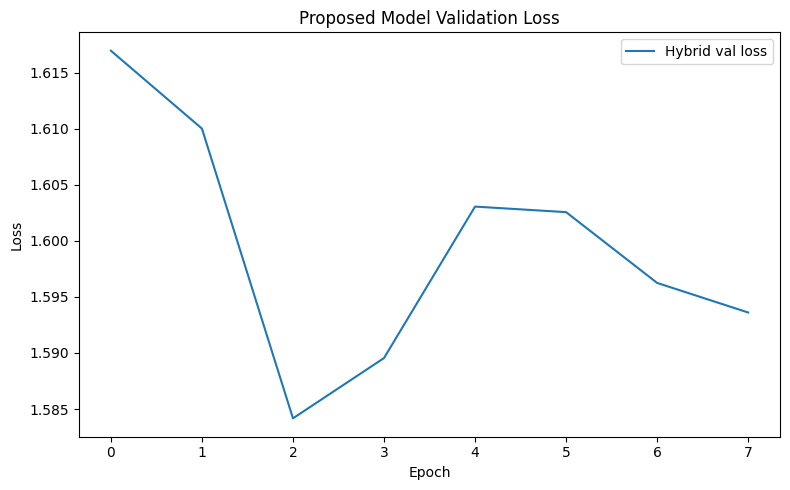

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['val_loss'], label='Hybrid val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Proposed Model Validation Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=300)
plt.show()


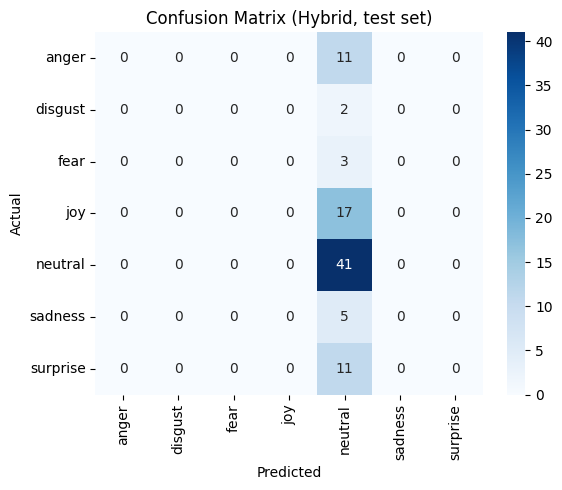

In [21]:
hybrid_logits, hybrid_targets = test_predictions["hybrid"]
hybrid_preds = hybrid_logits.argmax(axis=1)
plt.figure(figsize=(6, 5))
cm = confusion_matrix(hybrid_targets, hybrid_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=cats, yticklabels=cats)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (Hybrid, test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_or_scatter.png"), dpi=300); plt.show()


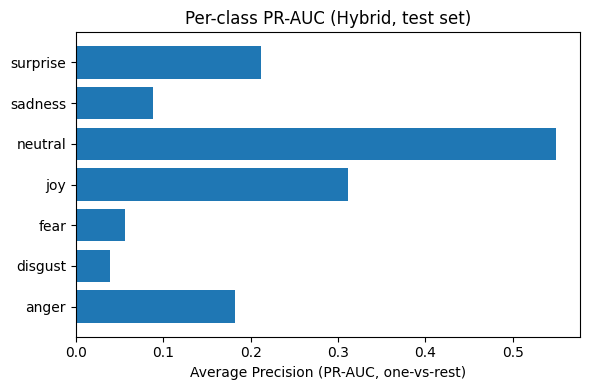

In [22]:
from sklearn.preprocessing import label_binarize
y_bin = label_binarize(hybrid_targets, classes=list(range(N_CLASSES)))
probs = torch.softmax(torch.tensor(hybrid_logits), dim=-1).numpy()
per_class_ap = [average_precision_score(y_bin[:, c], probs[:, c]) for c in range(N_CLASSES)]
plt.figure(figsize=(6, 4))
plt.barh(cats, per_class_ap)
plt.xlabel("Average Precision (PR-AUC, one-vs-rest)")
plt.title("Per-class PR-AUC (Hybrid, test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig03_roc_pr_curve.png"), dpi=300); plt.show()


### Error Analysis

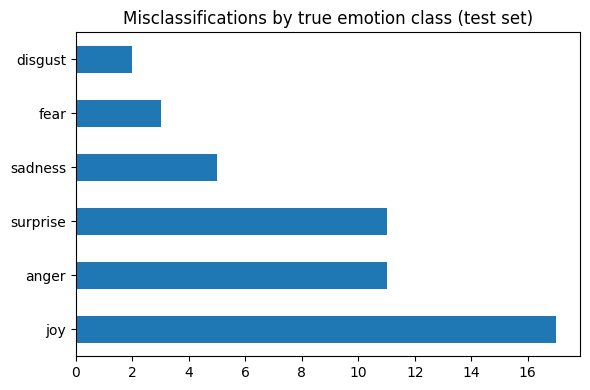

Total misclassified: 49 / 90


In [23]:
misclassified = hybrid_preds != hybrid_targets
per_class_error = pd.Series(hybrid_targets[misclassified]).value_counts()
per_class_error.index = [cats[i] for i in per_class_error.index]
plt.figure(figsize=(6, 4))
per_class_error.plot(kind="barh")
plt.title("Misclassifications by true emotion class (test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=300); plt.show()
print(f"Total misclassified: {misclassified.sum()} / {len(hybrid_targets)}")


### Computational Efficiency

In [24]:
import time
efficiency = {}
for name, model, forward in [('hybrid', hybrid, lambda m, xt, xf, xm: m(xt, xf, xm)[0])]:
    total_params = sum((p.numel() for p in model.parameters()))
    trainable_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
    model.eval()
    xt_b, xf_b, xm_b, _ = next(iter(test_loader))
    xt_b, xf_b, xm_b = (xt_b.to(DEVICE), xf_b.to(DEVICE), xm_b.to(DEVICE))
    with torch.no_grad():
        for _ in range(3):
            forward(model, xt_b, xf_b, xm_b)
        start = time.time()
        for _ in range(10):
            forward(model, xt_b, xf_b, xm_b)
        elapsed = (time.time() - start) / 10
    efficiency[name] = {'total_params': total_params, 'trainable_params': trainable_params, 'avg_batch_inference_time_sec': elapsed, 'throughput_samples_per_sec': xt_b.shape[0] / elapsed}
print(json.dumps(efficiency, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'efficiency.json'), 'w') as f:
    json.dump(efficiency, f, indent=2)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


...

/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_11196/2293028303.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=16000, duration=3.0)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


{
  "hybrid": {
    "total_params": 190778,
    "trainable_params": 190778,
    "avg_batch_inference_time_sec": 0.0037905216217041016,
    "throughput_samples_per_sec": 4221.054935654712
  }
}
